# Visualizador de curvas Nelson-Siegel

Notebook auxiliar: ingresá las fechas que querés comparar y el grupo, y genera el gráfico de curvas NS superpuestas.

**Uso:**
1. Modificá `FECHAS` y `GRUPO` en la celda de parámetros
2. Ejecutá todo el notebook (Run All)

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from sqlalchemy import text
from src.db.session import SessionLocal

print('Setup OK')

Setup OK


In [2]:
# ══════════════════════════════════════════════════════
#  PARÁMETROS — MODIFICAR ACÁ
# ══════════════════════════════════════════════════════

FECHAS = [
    '2025-12-24',   # anomalía CER (D_M=4.801)
    '2026-01-19',   # anomalía CER (D_M=4.394)
    '2026-01-29',   # anomalía CER (D_M=3.536)
    '2026-02-18',   # anomalía CER (D_M=3.180)
    '2026-02-19',   # anomalía CER (D_M=3.343)
]

# 'lecer', 'cer', o 'ambos'
GRUPO = 'cer'

# ══════════════════════════════════════════════════════

In [3]:
# ── Parsear y validar fechas ──────────────────────────
fechas_dt = []
for s in FECHAS:
    try:
        fechas_dt.append(pd.Timestamp(s).normalize())
    except Exception:
        print(f'  Fecha inválida ignorada: {s!r}')

fechas_dt = sorted(set(fechas_dt))
grupos_a_cargar = ['lecer', 'cer'] if GRUPO == 'ambos' else [GRUPO]

print(f'Fechas a graficar: {[f.date() for f in fechas_dt]}')
print(f'Grupo(s): {grupos_a_cargar}')

Fechas a graficar: [datetime.date(2025, 12, 24), datetime.date(2026, 1, 19), datetime.date(2026, 1, 29), datetime.date(2026, 2, 18), datetime.date(2026, 2, 19)]
Grupo(s): ['cer']


In [4]:
# ── Carga de datos ────────────────────────────────────
datos = {}   # grupo → DataFrame

with SessionLocal() as db:
    for grp in grupos_a_cargar:
        df = pd.read_sql(
            text("""
                SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
                FROM precios_raw p
                JOIN metricas_diarias m ON m.precio_id = p.id
                JOIN bonos b ON b.ticker = p.ticker
                WHERE b.grupo = :grp
                  AND p.fecha = ANY(:fechas)
                ORDER BY p.fecha, m.duration_modificada
            """),
            db.bind,
            params={
                'grp':   grp,
                'fechas': [f.date() for f in fechas_dt],
            },
            parse_dates=['fecha']
        )
        df['tir']                = df['tir'].astype(float)
        df['duration_modificada'] = df['duration_modificada'].astype(float)
        df = df.dropna(subset=['tir', 'duration_modificada'])
        datos[grp] = df
        print(f'{grp.upper()}: {len(df)} obs en {df["fecha"].nunique()} fecha(s)')

# Advertir fechas sin datos
for f in fechas_dt:
    for grp in grupos_a_cargar:
        if f not in datos[grp]['fecha'].values:
            print(f'  Sin datos: {grp.upper()} el {f.date()}')

CER: 80 obs en 5 fecha(s)


In [5]:
# ── Modelo Nelson-Siegel ──────────────────────────────

def nelson_siegel(tau, beta0, beta1, beta2, lam):
    with np.errstate(over='ignore', invalid='ignore'):
        x  = tau / lam
        f1 = np.where(x < 1e-10, 1.0, (1.0 - np.exp(-x)) / x)
        f2 = f1 - np.exp(-x)
    return beta0 + beta1 * f1 + beta2 * f2


def ajustar_ns(df_dia, min_puntos=3):
    df_dia = df_dia[df_dia['duration_modificada'] > 0].dropna(
        subset=['tir', 'duration_modificada'])
    if len(df_dia) < min_puntos:
        return None
    d = df_dia['duration_modificada'].values
    y = df_dia['tir'].values
    idx = np.argsort(d)
    slope_init = float(y[idx[0]] - y[idx[-1]])
    try:
        popt, _ = curve_fit(
            nelson_siegel, d, y,
            p0=[float(np.mean(y)), slope_init, 0.0, 1.0],
            bounds=([-0.5, -0.5, -0.5, 0.05], [0.5, 0.5, 0.5, 10.0]),
            maxfev=5000
        )
        beta0, beta1, beta2, lam = popt
    except Exception:
        return None
    y_pred  = nelson_siegel(d, beta0, beta1, beta2, lam)
    rmse_pp = float(np.sqrt(np.mean(((y - y_pred) * 100) ** 2)))
    return {
        'beta0': beta0, 'beta1': beta1,
        'beta2': beta2, 'lam':   lam,
        'rmse_pp': rmse_pp,
        'tickers': df_dia['ticker'].values,
        'd': d, 'y': y,
    }


print('Funciones NS cargadas')

Funciones NS cargadas


In [6]:
# ── Ajustar NS por fecha y grupo ──────────────────────
resultados = {}   # (grupo, fecha) → dict resultado NS

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for grp, df in datos.items():
        for fecha, grupo_df in df.groupby('fecha'):
            res = ajustar_ns(grupo_df)
            if res is not None:
                resultados[(grp, fecha)] = res
            else:
                print(f'  Ajuste NS fallido: {grp.upper()} el {fecha.date()} '
                      f'(n={len(grupo_df)} bonos)')

print(f'\nAjustes exitosos: {len(resultados)} / '
      f'{sum(df["fecha"].nunique() for df in datos.values())}')


Ajustes exitosos: 5 / 5


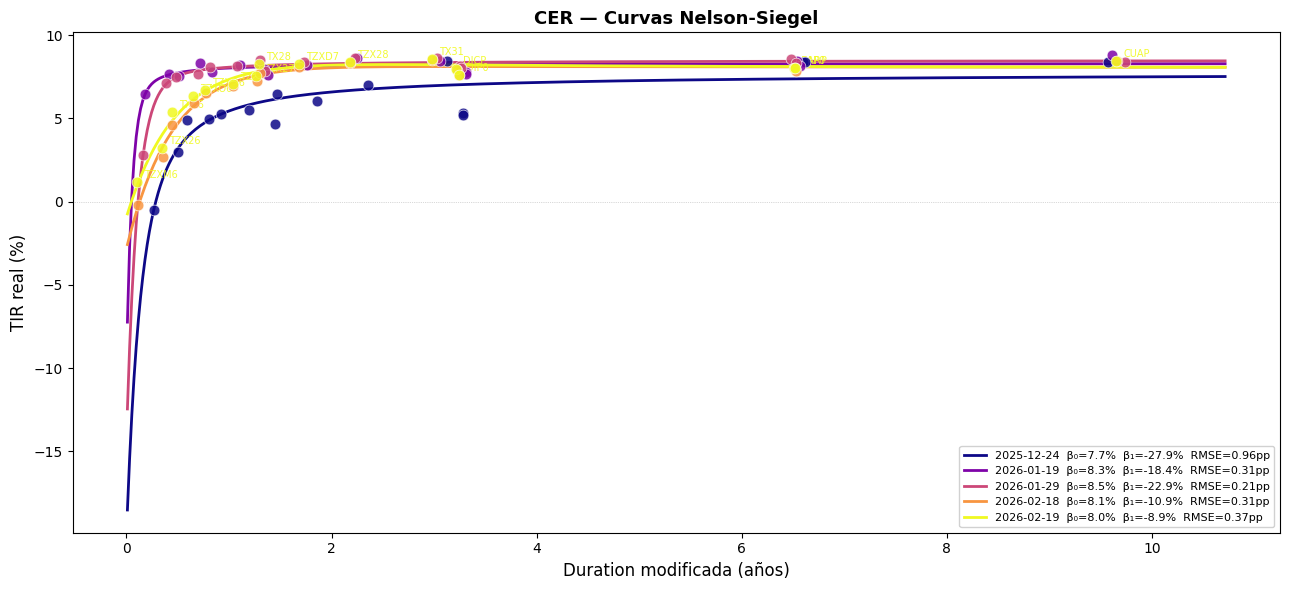

In [7]:
# ── Gráfico ───────────────────────────────────────────

def plot_curvas(grupo, titulo_extra=''):
    claves = [(g, f) for (g, f) in resultados if g == grupo]
    if not claves:
        print(f'Sin ajustes para {grupo.upper()}')
        return

    claves = sorted(claves, key=lambda x: x[1])
    n = len(claves)
    colores = [cm.plasma(i / max(n - 1, 1)) for i in range(n)]

    fig, ax = plt.subplots(figsize=(13, 6))

    d_max_global = max(
        resultados[k]['d'].max() for k in claves
    )
    tau = np.linspace(0.01, d_max_global * 1.1, 500)

    for (grp, fecha), color in zip(claves, colores):
        res = resultados[(grp, fecha)]
        y_ns = nelson_siegel(tau, res['beta0'], res['beta1'],
                             res['beta2'], res['lam']) * 100

        label = (f"{fecha.date()}  "
                 f"β₀={res['beta0']*100:.1f}%  "
                 f"β₁={res['beta1']*100:.1f}%  "
                 f"RMSE={res['rmse_pp']:.2f}pp")

        ax.plot(tau, y_ns, color=color, linewidth=2.0,
                label=label, zorder=3)

        # Puntos reales
        ax.scatter(res['d'], res['y'] * 100,
                   color=color, s=60, zorder=5, alpha=0.85,
                   edgecolors='white', linewidths=0.5)

        # Etiquetas de tickers (solo en la fecha más reciente para no saturar)
        if fecha == claves[-1][1]:
            for dur, tir, ticker in zip(res['d'], res['y'] * 100, res['tickers']):
                ax.annotate(ticker, (dur, tir),
                            textcoords='offset points', xytext=(5, 3),
                            fontsize=7, color=color, alpha=0.9)

    ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.3)
    ax.set_xlabel('Duration modificada (años)', fontsize=12)
    ax.set_ylabel('TIR real (%)', fontsize=12)
    titulo = f'{grupo.upper()} — Curvas Nelson-Siegel'
    if titulo_extra:
        titulo += f'  {titulo_extra}'
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='best', framealpha=0.9)
    plt.tight_layout()
    plt.show()


for grp in grupos_a_cargar:
    plot_curvas(grp)

In [8]:
# ── Tabla de parámetros por fecha ─────────────────────
rows = []
for (grp, fecha), res in sorted(resultados.items()):
    rows.append({
        'grupo':    grp,
        'fecha':    fecha.date(),
        'β₀ (%)':  round(res['beta0'] * 100, 3),
        'β₁ (%)':  round(res['beta1'] * 100, 3),
        'β₂ (%)':  round(res['beta2'] * 100, 3),
        'λ':        round(res['lam'], 4),
        'RMSE (pp)': round(res['rmse_pp'], 4),
        'n_bonos':  len(res['d']),
    })

df_tabla = pd.DataFrame(rows)
print(df_tabla.to_string(index=False))

grupo      fecha  β₀ (%)  β₁ (%)  β₂ (%)      λ  RMSE (pp)  n_bonos
  cer 2025-12-24   7.733 -27.884  -0.002 0.0819     0.9618       16
  cer 2026-01-19   8.319 -18.379  12.643 0.0500     0.3124       16
  cer 2026-01-29   8.501 -22.949  18.715 0.0991     0.2082       16
  cer 2026-02-18   8.062 -10.884  11.368 0.4413     0.3100       16
  cer 2026-02-19   8.010  -8.941  10.446 0.4795     0.3725       16
